# Proyecto 2 · C1: ingeniería de datos y secuencias
**José Auyón · CC3092 Deep Learning**

Este notebook ejecuta C1 desde los CSV originales, documenta las decisiones y entrega el mismo contrato a la etapa A, etapa B, línea base y MVP. Las gráficas aparecen antes de cualquier modelado.

La comparación detallada de PaySim y las seis variantes IBM está en `notebooks/comparacion_datasets.ipynb`. PaySim se mantiene como análisis exploratorio; IBM AML HI-Small se usa para modelar porque ofrece historiales por remitente. Fraude y lavado son etiquetas distintas y no se mezclan.

## Decisiones de diseño

- Selección uniforme de 50,000 cuentas emisoras, semilla 42 y sin consultar labels.
- Historial ordenado por tiempo; empate resuelto por el índice original de fila.
- Últimas 64 operaciones. La etiqueta se recalcula después del recorte.
- Secuencia por cuenta; split por `Entity ID` para mantener juntas las cuentas del mismo actor.
- Features causales: monto, ritmo, frecuencia, tiempo, banco, repetición de destinatario, moneda y formato.
- Estadísticas numéricas ajustadas solo con normalidad de entrenamiento; vocabularios ajustados con todo entrenamiento.
- Prevalencia natural, sin SMOTE. `pos_weight` se entrega para que C2B decida cómo usarlo.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "data" / "sequences.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Ejecutar desde la raíz del proyecto o desde notebooks/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.sequences import build_artifacts, get_sender, make_dataloaders

CSV_PATH = ROOT / "datasets" / "IBM" / "HI-Small_Trans.csv"
ARTIFACT_DIR = ROOT / "artifacts" / "c1_hi_small"
REPORT_DIR = ROOT / "reports" / "c1"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Falta {CSV_PATH}")
print(f"Proyecto: {ROOT}")
print(f"Fuente: {CSV_PATH.name} ({CSV_PATH.stat().st_size / 1e9:.2f} GB)")

Proyecto: D:\UVG\DL\Proyecto2_DL
Fuente: HI-Small_Trans.csv (0.48 GB)


## Construcción reproducible

La celda lee `HI-Small_Trans.csv` completo dos veces: primero valida todas las filas y selecciona remitentes; después conserva sus historiales. También valida y cruza Accounts. Sobrescribe únicamente los cinco artefactos conocidos dentro de `artifacts/c1_hi_small`.

In [2]:
manifest = build_artifacts(
    CSV_PATH,
    ARTIFACT_DIR,
    n_senders=50_000,
    max_len=64,
    seed=42,
)
print(f"Pipeline completo: {manifest['runtime']['total_seconds']:.1f} s")
print(f"Contrato v{manifest['contract_version']} · {len(manifest['feature_names'])} features")

Pipeline completo: 49.8 s
Contrato v1 · 33 features


## Resumen de selección, recorte y clases

In [3]:
counts = manifest["counts"]
summary_rows = [
    ("Fuente completa", counts["source_transactions"], counts["source_senders"]),
    ("Muestra antes del recorte", counts["selected_transactions_before_truncation"], counts["selected_senders"]),
    ("Muestra después del recorte", counts["retained_transactions"], counts["selected_senders"]),
]
display(pd.DataFrame(summary_rows, columns=["Estado", "Transacciones", "Remitentes"]))
display(pd.DataFrame([
    {
        "Estado": "Antes del recorte",
        "Remitentes positivos": counts["positive_senders_before_truncation"],
        "Transacciones positivas": counts["positive_transactions_before_truncation"],
    },
    {
        "Estado": "Después del recorte",
        "Remitentes positivos": counts["positive_senders_after_truncation"],
        "Transacciones positivas": counts["positive_transactions_after_truncation"],
    },
]))
print(f"Remitentes recortados: {counts['truncated_senders']:,} ({100*counts['truncated_senders']/counts['selected_senders']:.3f}%)")

,Estado,Transacciones,Remitentes
0,Fuente completa,5078345,496999
1,Muestra antes del recorte,464009,50000
2,Muestra después del recorte,426244,50000


,Estado,Remitentes positivos,Transacciones positivas
0,Antes del recorte,366,533
1,Después del recorte,362,525


Remitentes recortados: 1,307 (2.614%)


## Distribución de longitudes

La longitud original cuenta todas las operaciones del remitente seleccionado. La longitud retenida proviene de los offsets persistidos. El eje derecho amplía P90–P99 porque unos pocos historiales extremos hacen poco informativo el máximo.

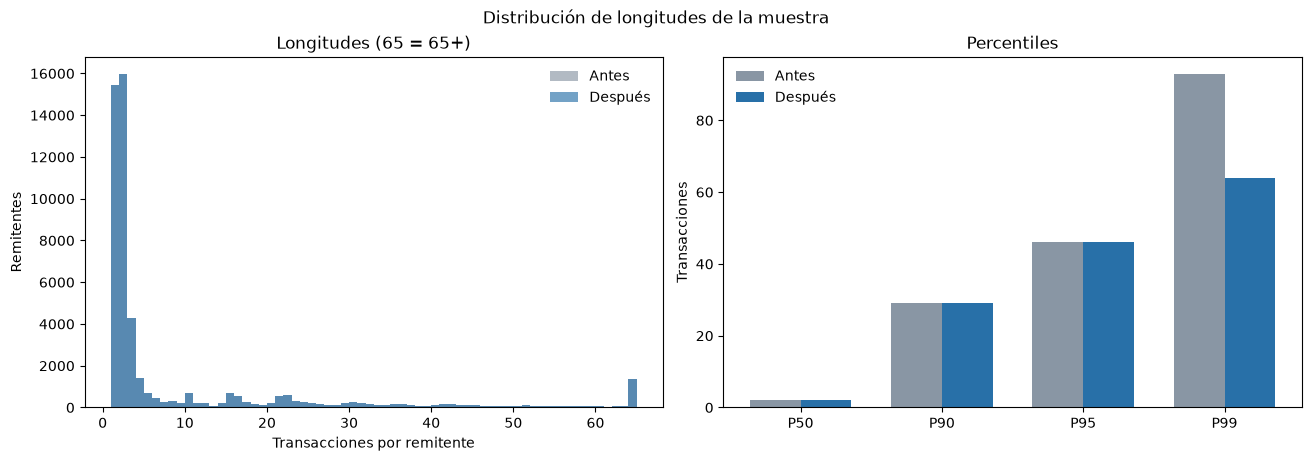

In [4]:
with np.load(ARTIFACT_DIR / manifest["artifacts"]["arrays"], allow_pickle=False) as loaded:
    arrays = {name: loaded[name] for name in loaded.files}
retained_lengths = np.diff(arrays["offsets"])
full_lengths = arrays["full_lengths"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
bins = np.arange(1, 66)
axes[0].hist(np.minimum(full_lengths, 65), bins=bins, alpha=.65, label="Antes", color="#8996a4")
axes[0].hist(np.minimum(retained_lengths, 65), bins=bins, alpha=.65, label="Después", color="#2870a8")
axes[0].set(title="Longitudes (65 = 65+)", xlabel="Transacciones por remitente", ylabel="Remitentes")
axes[0].legend(frameon=False)
quantiles = [50, 90, 95, 99]
before_q = np.percentile(full_lengths, quantiles, method="inverted_cdf")
after_q = np.percentile(retained_lengths, quantiles, method="inverted_cdf")
x = np.arange(len(quantiles))
width = .36
axes[1].bar(x-width/2, before_q, width, label="Antes", color="#8996a4")
axes[1].bar(x+width/2, after_q, width, label="Después", color="#2870a8")
axes[1].set(xticks=x, xticklabels=[f"P{q}" for q in quantiles], title="Percentiles", ylabel="Transacciones")
axes[1].legend(frameon=False)
fig.suptitle("Distribución de longitudes de la muestra")
fig.savefig(REPORT_DIR / "longitudes_secuencia.png", dpi=160)
plt.show()

## Splits sin entidades compartidas y prevalencia natural

,Split,Remitentes,Entidades,Positivos,% positivo
0,train,35000,29165,254,0.725714
1,validation,7500,1569,54,0.720000
2,test,7500,1569,54,0.720000


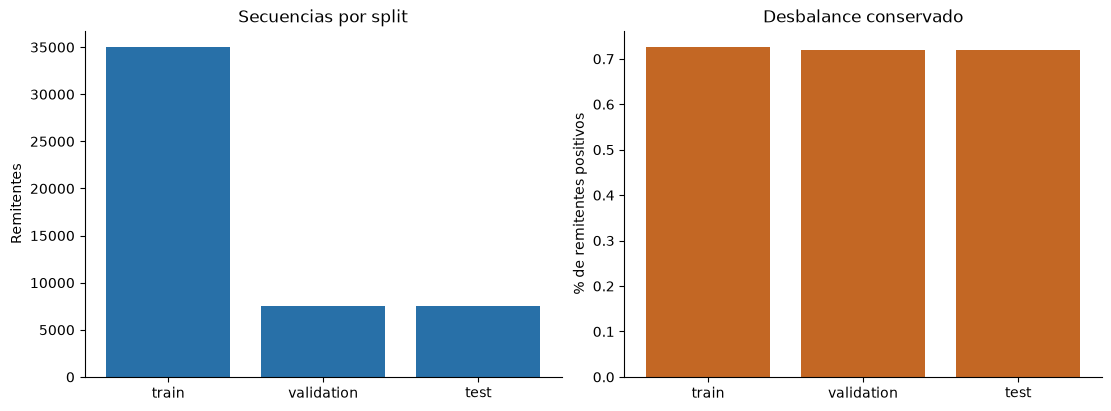

Entidades compartidas entre splits: 0 · pos_weight de entrenamiento: 136.7953


In [5]:
split_rows = []
for name in ("train", "validation", "test"):
    split = manifest["splits"][name]
    split_rows.append({
        "Split": name,
        "Remitentes": split["sender_count"],
        "Entidades": len(split["entity_ids"]),
        "Positivos": split["positive_sender_count"],
        "% positivo": 100 * split["positive_sender_count"] / split["sender_count"],
    })
split_frame = pd.DataFrame(split_rows)
display(split_frame)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].bar(split_frame["Split"], split_frame["Remitentes"], color="#2870a8")
axes[0].set(title="Secuencias por split", ylabel="Remitentes")
axes[1].bar(split_frame["Split"], split_frame["% positivo"], color="#c36724")
axes[1].set(title="Desbalance conservado", ylabel="% de remitentes positivos")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.savefig(REPORT_DIR / "splits_y_clases.png", dpi=160)
plt.show()

entity_sets = [set(manifest["splits"][name]["entity_ids"]) for name in ("train", "validation", "test")]
assert not (entity_sets[0] & entity_sets[1] or entity_sets[0] & entity_sets[2] or entity_sets[1] & entity_sets[2])
print(f"Entidades compartidas entre splits: 0 · pos_weight de entrenamiento: {counts['pos_weight']:.4f}")

## Representación por transacción

Las tres primeras variables se estandarizan. Las variables de tiempo son cíclicas; los indicadores y one-hot permanecen en su escala natural. La columna `<UNK>` permite inferencia con categorías ausentes durante entrenamiento.

In [6]:
preprocessor = json.loads((ARTIFACT_DIR / manifest["artifacts"]["preprocessor"]).read_text(encoding="utf-8"))
display(pd.DataFrame({
    "Feature numérica": preprocessor["numeric_features"],
    "Media train normal": preprocessor["numeric_mean"],
    "Escala train normal": preprocessor["numeric_scale"],
}))
display(pd.DataFrame({"Índice": range(len(manifest["feature_names"])), "Feature": manifest["feature_names"]}))

,Feature numérica,Media train normal,Escala train normal
0,log_amount_paid,7.515121,3.192622
1,log_delta_hours,1.142519,1.413100
2,log_previous_24h,1.264543,0.849074


,Índice,Feature
0,0,log_amount_paid_z
1,1,log_delta_hours_z
2,2,log_previous_24h_z
3,3,hour_sin
4,4,hour_cos
5,5,weekday_sin
6,6,weekday_cos
7,7,cross_bank
8,8,destination_seen_before
9,9,currency=<UNK>


## Tres pares de secuencias normales y sospechosas

Se eligen de entrenamiento con longitud mínima de tres y semilla fija. Cada panel conserva el orden temporal. Los puntos rojos indican transacciones con label de lavado; las líneas pueden unir importes expresados en monedas diferentes y sirven para mostrar el patrón temporal, no para sumar valor económico entre monedas.

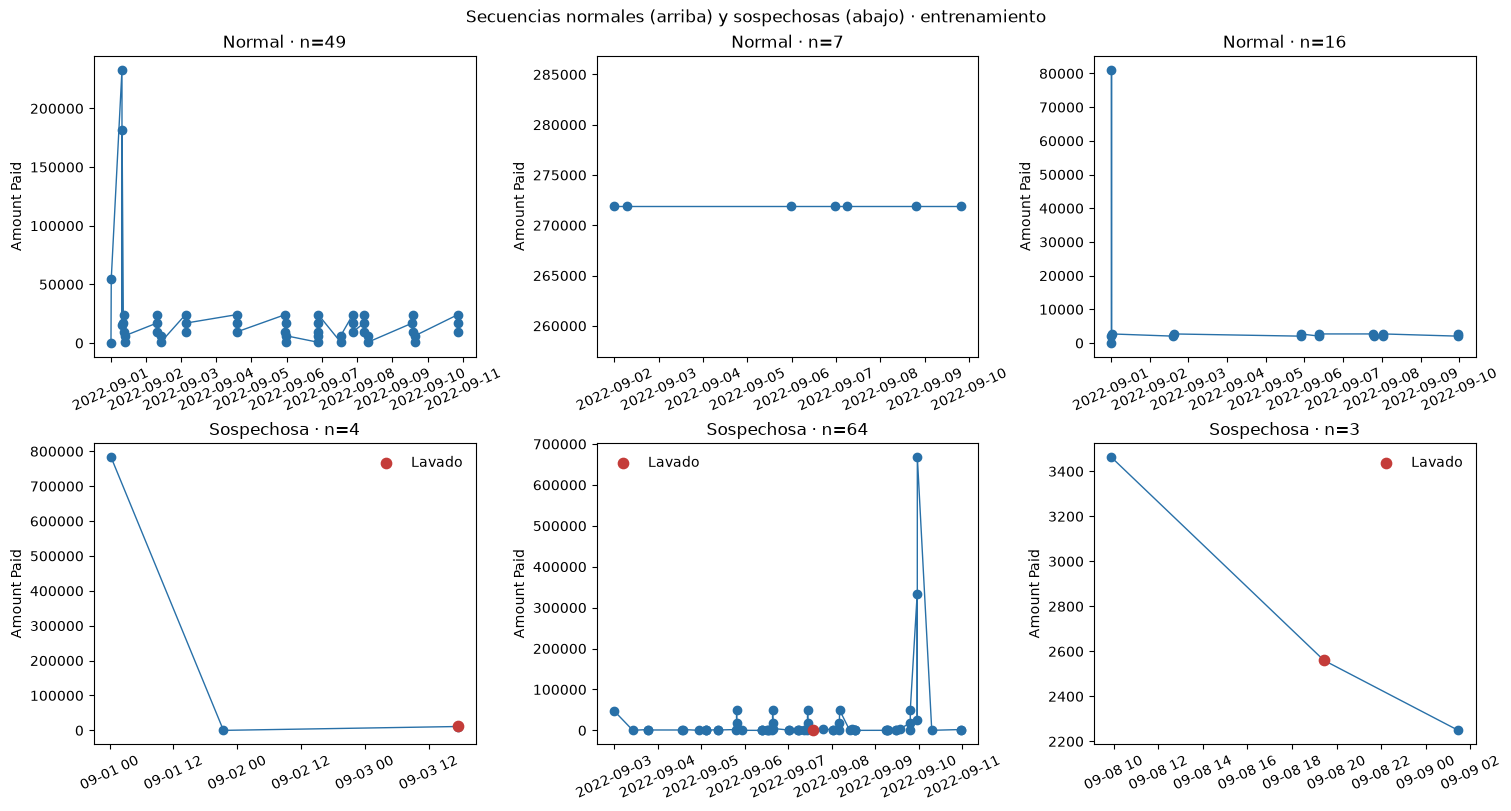

In [7]:
rng = np.random.default_rng(42)
train_indices = np.flatnonzero(arrays["split_codes"] == 0)
eligible = train_indices[retained_lengths[train_indices] >= 3]
positive = eligible[arrays["y"][eligible] == 1]
negative = eligible[arrays["y"][eligible] == 0]
chosen = np.concatenate([rng.choice(negative, 3, replace=False), rng.choice(positive, 3, replace=False)])

fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
for panel, index in zip(axes.flat, chosen):
    sender_id = str(arrays["sender_ids"][index])
    sample = get_sender(sender_id, ARTIFACT_DIR, split="train")
    frame = pd.DataFrame(sample["transactions"])
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], format="%Y/%m/%d %H:%M")
    panel.plot(frame["timestamp"], frame["amount_paid"], marker="o", color="#2870a8", linewidth=1)
    suspicious = frame["is_laundering"] == 1
    panel.scatter(frame.loc[suspicious, "timestamp"], frame.loc[suspicious, "amount_paid"], color="#c43c39", s=55, zorder=3, label="Lavado")
    panel.set_title(("Normal" if sample["y"].item() == 0 else "Sospechosa") + f" · n={len(frame)}")
    panel.set_ylabel("Amount Paid")
    panel.tick_params(axis="x", rotation=25)
    if suspicious.any():
        panel.legend(frameon=False)
fig.suptitle("Secuencias normales (arriba) y sospechosas (abajo) · entrenamiento")
fig.savefig(REPORT_DIR / "ejemplos_secuencias.png", dpi=160)
plt.show()

## Contrato para Ruiz, Gerardo y el MVP

In [8]:
loaders = make_dataloaders(ARTIFACT_DIR, batch_size=128, seed=42)
example = next(iter(loaders["train_normal"]))
display(pd.DataFrame([
    {"Campo": "x", "Forma": str(tuple(example["x"].shape)), "Tipo": str(example["x"].dtype)},
    {"Campo": "mask", "Forma": str(tuple(example["mask"].shape)), "Tipo": str(example["mask"].dtype)},
    {"Campo": "lengths", "Forma": str(tuple(example["lengths"].shape)), "Tipo": str(example["lengths"].dtype)},
    {"Campo": "y", "Forma": str(tuple(example["y"].shape)), "Tipo": str(example["y"].dtype)},
    {"Campo": "transaction_ids", "Forma": str(tuple(example["transaction_ids"].shape)), "Tipo": str(example["transaction_ids"].dtype)},
]))
assert not example["y"].bool().any()
assert (example["mask"].sum(axis=1) == example["lengths"]).all()
assert (example["transaction_ids"][~example["mask"]] == -1).all()
print("train_normal contiene solo normalidad; máscara y padding son coherentes.")

,Campo,Forma,Tipo
0,x,"(128, 64, 33)",torch.float32
1,mask,"(128, 64)",torch.bool
2,lengths,"(128,)",torch.int64
3,y,"(128,)",torch.float32
4,transaction_ids,"(128, 64)",torch.int64


train_normal contiene solo normalidad; máscara y padding son coherentes.


## Validación de integridad

Estas comprobaciones no sustituyen las pruebas unitarias. Verifican el artefacto real generado en esta ejecución.

In [9]:
assert arrays["x_values"].dtype == np.float32
assert np.isfinite(arrays["x_values"]).all()
assert len(arrays["sender_ids"]) == 50_000
assert len(set(arrays["sender_ids"].tolist())) == 50_000
assert arrays["offsets"][-1] == len(arrays["x_values"]) == counts["retained_transactions"]
assert set(np.unique(arrays["y"])).issubset({0.0, 1.0})
assert int(arrays["y"].sum()) == counts["positive_senders_after_truncation"]
assert arrays["transaction_ids"].size == np.unique(arrays["transaction_ids"]).size
assert len(manifest["source"]["transactions_sha256"]) == 64
assert len(manifest["source"]["accounts_sha256"]) == 64
print("Artefactos reales: IDs únicos, shapes, labels, offsets, valores finitos y huellas válidas.")

Artefactos reales: IDs únicos, shapes, labels, offsets, valores finitos y huellas válidas.


## Limitaciones de C1

- IBM AML es sintético y no representa directamente el corredor Guatemala–Estados Unidos.
- `y=0` significa que no hay una operación etiquetada dentro del historial retenido; no certifica legitimidad.
- La división generaliza a entidades no vistas, pero no es prospectiva en el tiempo.
- Destinatarios y bancos sí pueden aparecer en varios splits.
- El recorte elimina cuatro remitentes positivos y ocho transacciones positivas de la muestra.
- El archivo completo del notebook debe volver a medirse en Colab T4 cuando C2A, C2B y la ablación estén integrados.

# C2A — Etapa A: aprendizaje de normalidad

Sección reservada para la implementación y resultados de Jose Ruiz. Debe consumir `loaders["train_normal"]`, aplicar `mask` a reconstrucción y guardar un encoder/checkpoint compatible con las 33 features.

# C2B — Transfer learning, combinación y ablación

Sección reservada para Gerardo Fernandez. Debe usar los mismos splits de este manifiesto, comparar contra una línea base desde cero y producir contribuciones por transacción alineadas con `transaction_ids`.

# Interpretabilidad e integración del MVP

Las filas de `get_sender` mantienen el orden del tensor, lo que permite alinear atención, heatmap y explicación. La integración final se ejecutará cuando los checkpoints y resultados de C2 estén disponibles.